# Comparación de datos numéricos vs. numéricos

En esta lección veremos las técnicas más usadas para realizar el análisis bivariado de variables numéricas. En particular veremos:

1. La correlación
2. La matriz de correlación
3. Los gráficos de dispersión (*scatter plots*)
4. Los mapas hexagonales (*hex binings*) y los mapas de contorno o de curvas de contorno (*contour maps*)

Por cada una de estas herramientas veremos qué es, cuándo usarla y un ejemplo práctico de uso enfocado al análisis exploratorio.

## 1. La correlación

En la lección 2 ("La correlación") del curso "Probabilidad Nivel Avanzado" hablamos en detalle de la correlación.

De manera simple:

> La correlación mide el grado de relación que hay entre dos variables numéricas.

Esta correlación varía en el rango de -1 a 1:

- Si es cercana a -1 tenemos una relación **inversa** entre las variables (si la una aumenta la otra disminuye)
- Si es cercana a 1 la relación es **directa** (ambas variables cambian proporcionalmente)
- Si es cercana a 0 prácticamente no están relacionadas

Veamos cómo calcular la correlación entre pares de variables numéricas. Comencemos leyendo el set de datos *etfs-retornos-diarios.csv* que contiene los porcentajes de retorno diario entregados por diferentes ETFs (*exchange-traded funds* o fondos cotizados):

In [1]:
# Leer el set de datos
import pandas as pd

ruta = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/21-2024-03-Estadística-Descriptiva/datos/'
etfs = pd.read_csv(ruta + 'etfs-retornos-diarios.csv')
etfs

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
0,-0.376098,0.096313,0.028223,-0.242796,0.419998,-10.400000,0.000000,0.534641,0.028186,0.095759,0.098311,-0.093713,0.019076,-0.009529,0.313499,0.018999,0.075668
1,0.376099,0.481576,0.874936,0.728405,0.490006,-3.520000,0.250000,0.926067,0.995942,0.000000,-0.044686,0.337373,0.000000,0.000000,0.129087,0.104492,0.236462
2,0.150440,0.096313,-0.103487,0.149420,0.239991,6.560000,-0.070000,-0.171848,-0.460387,0.306431,-0.151938,0.103086,0.019072,-0.142955,-0.073766,-0.142490,0.066211
3,-0.141040,-0.491201,0.018819,-0.205449,-0.519989,-8.800000,-0.180000,-0.229128,0.206706,0.153214,0.080437,0.018744,-0.429213,-0.095304,0.119865,0.066495,-0.227003
4,0.244465,-0.048160,-0.056445,-0.168094,0.429992,-0.480000,0.459999,-0.190939,-0.234892,-0.201098,-0.035751,-0.168687,0.000000,0.352630,-0.064548,0.018999,0.009457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,-0.379997,-0.669998,-1.270004,-1.398679,0.010002,0.279999,-0.069999,-0.497896,-0.750000,-0.200005,-0.309997,-0.059997,-0.229999,0.189994,-0.279999,-0.220002,-0.330002
750,-0.040001,-0.700004,-0.389999,-0.079926,0.360001,-0.020001,0.189999,-0.587512,0.259995,-0.010002,0.340000,-0.290001,-0.280002,-0.220001,0.029998,-0.030001,-0.330002
751,-0.590000,-1.320000,-2.580002,-1.918189,0.260002,1.829999,-0.080000,-2.280327,-0.500000,-1.089996,-0.160000,-0.769996,-0.700001,-1.180000,-0.500000,-0.330000,-0.450000
752,-0.480000,-0.419998,-1.369996,-1.168887,0.130005,0.889999,0.139999,-0.338568,-0.169998,-0.430001,-0.310001,-0.270001,0.259999,-0.510002,-0.580002,-0.150002,-0.269996


Algunos de estos fondos contienen acciones de empresas en estos sectores:

- Sector Tecnológico: QQQ, XLK
- Sector energético: XLE, USO
- Sector de consumo: XLY, XLP
- Sector de Salud: XLV
- Sector financiero: XLF
- Sector de materias primas: XLB

Midamos por ejemplo el grado de relación entre un ETF del sector tecnológico (como por ejemplo QQQ) con uno del sector energético (por ejemplo USO). Para ello podemos usar el método `corr()`:

In [2]:
etfs['QQQ'].corr(etfs['USO'])

0.19949158785354248

¿Qué nos dice este índice de correlación?

Que las variaciones diarias (retornos) de las empresas del sector tecnológico (medidas a través del ETF QQQ) **no están prácticamente relacionadas** con aquellas de las empresas del sector energético (medidas a través del ETF USO).

¿Qué pasa si comparamos ETFs del mismo sector, por ejemplo XLY y XLP?:

In [3]:
etfs['XLY'].corr(etfs['XLP'])

0.663055480571772

Acá hay un mayor grado de **correlación positiva** que nos indica que incrementos en un ETF están asociados a incrementos en el otro.

## 2. La matriz de correlación

Cuando tenemos múltiples variables numéricas (como en el caso del set de datos anterior, que contiene 17 variables) no resulta práctico realizar la correlación por pares individuales para luego extraer información relevante.

Lo más práctico es mostrar esta información de manera condensada en una matriz que se conoce como la **matriz de correlación**. En esta matriz simplemente mostramos de manera organizada los índices de correlación existentes entre todos los posibles pares de variables.

Para calcularla podemos usar el método `corr()` aplicado sobre el *DataFrame*:

In [4]:
# Matriz de correlación para todas las variables numéricas
etfs.corr()

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
XLI,1.000000,0.785865,0.888865,0.869680,0.056554,-0.468196,0.236881,0.782380,0.650054,0.798080,0.380809,0.784144,0.374000,0.663022,0.600424,0.787340,0.777773
QQQ,0.785865,1.000000,0.908995,0.834440,0.043553,-0.470555,0.199492,0.810158,0.560044,0.839701,0.346667,0.713463,0.421790,0.775392,0.614806,0.752771,0.945126
SPY,0.888865,0.908995,1.000000,0.953726,0.078722,-0.547074,0.272069,0.833937,0.713300,0.887028,0.481928,0.826053,0.406181,0.811269,0.744466,0.883616,0.886588
DIA,0.869680,0.834440,0.953726,1.000000,0.051523,-0.511327,0.256793,0.758012,0.658311,0.847043,0.463364,0.787415,0.383928,0.771044,0.753725,0.860556,0.842757
GLD,0.056554,0.043553,0.078722,0.051523,1.000000,-0.107488,0.216563,0.070110,0.188625,0.017467,0.121611,0.184366,-0.042233,-0.010200,0.033047,0.043039,0.053022
VXX,-0.468196,-0.470555,-0.547074,-0.511327,-0.107488,1.000000,-0.195397,-0.448942,-0.448474,-0.474756,-0.260395,-0.470890,-0.205661,-0.380925,-0.416913,-0.514365,-0.477258
USO,0.236881,0.199492,0.272069,0.256793,0.216563,-0.195397,1.000000,0.249799,0.525943,0.183275,0.113182,0.324166,0.078796,0.119500,0.116857,0.221760,0.225962
IWM,0.782380,0.810158,0.833937,0.758012,0.070110,-0.448942,0.249799,1.000000,0.586991,0.779750,0.325003,0.701533,0.387274,0.664288,0.537065,0.756282,0.760438
XLE,0.650054,0.560044,0.713300,0.658311,0.188625,-0.448474,0.525943,0.586991,1.000000,0.578956,0.337942,0.689778,0.260463,0.454457,0.413486,0.599129,0.559324
XLY,0.798080,0.839701,0.887028,0.847043,0.017467,-0.474756,0.183275,0.779750,0.578956,1.000000,0.366827,0.721232,0.370299,0.702860,0.663055,0.782053,0.772189


Algunas características importantes de esta matriz:

- Es una **matriz cuadrada** donde el número de filas y columnas es el mismo e igual al número de variables (en el caso anterior la matriz será de 17x17.
- Cada elemento $a_{i,j}$ de la matriz es el índice de correlación entre la variable $i$ y la variable $j$
- Los elementos $a_{i,i}$ (diagonal principal) **siempre tendrán valores iguales a 1** pues corresponden al índice de correlación de la variable consigo misma
- Es una matriz simétrica con respecto a la diagonal principal: es lo mismo el índice de correlación $a_{i,j}$ que el índice $a_{j,i}$

Aunque con esta matriz ya resulta más sencillo extraer conclusiones a partir de las diferentes comparaciones, aún se dificulta el proceso pues tenemos demasiadas variables.

Esto se facilita generando un **mapa de calor** (*heatmap*) donde los números (resultado de cada correlación) se mostrarán con un color determinado.

Podemos crear este mapa de calor usando el método `heatmap()` de Seaborn combinado con el método `corr()` de Pandas usado anteriormente:

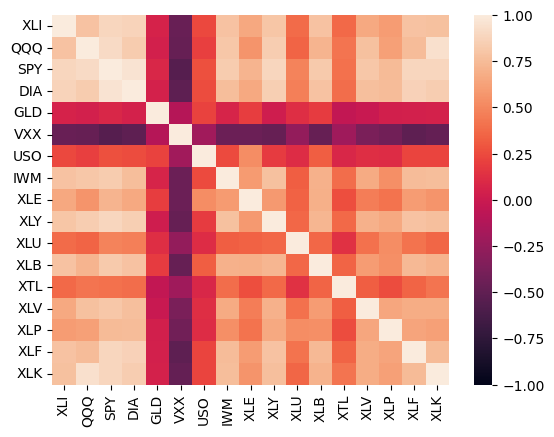

In [5]:
# Matriz de correlación
import seaborn as sns

ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1);

Y ahora sí resulta más fácil interpretar las diferentes correlaciones. Dependiendo del [mapa de color](https://seaborn.pydata.org/tutorial/color_palettes.html) usado resultará más o menos sencilla la interpretación.

Modifiquemos la gráfica anterior usando por ejemplo el mapa "vlag":

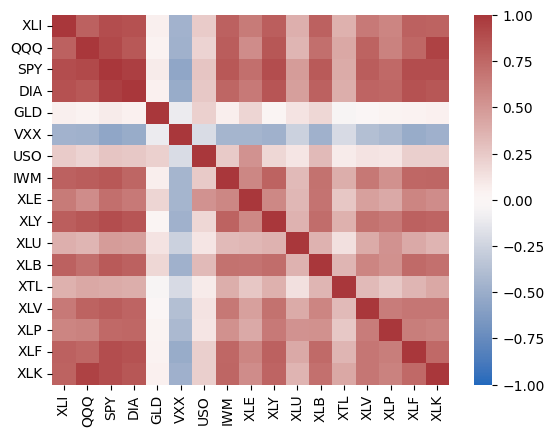

In [6]:
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap="vlag");

Y acá podemos hacer algunas observaciones importantes antes de realizar el análisis exploratorio:

1. Las correlaciones inversas (cercanas a -1.0) tienen tonalidades azul oscuro
2. Las correlaciones directas (cercanas a +1.0) tienen tonalidades cercanas al rojo oscuro
3. Cuando el nivel de correlación es bajo (valores cercanos a 0.0) las tonalidades serán casi blancas

Ahora sí podemos escribir algunas observaciones respecto al Análisis Exploratorio. Por ejemplo planteemos algunas preguntas:

1. Si queremos invertir en ETFs del sector tecnológico, ¿qué otras alternativas a QQQ podríamos considerar?

Al observar la matriz de correlación podríamos responder que los ETFs SPY y XLK tienen comportamientos similares al QQQ

2. Si nos interesa invertir en bienes como el oro (GLD) qué otros ETFs podríamos considerar

Al observar la matriz de correlación vemos que realmente no existen ETFs con un comportamiento similar al GLD.

## 3. Gráficos de dispersión (*scatter plots*)

Son otra manera de ver la correlación entre pares de variables. En este caso lo que hacemos es poner cada variable en un eje de la gráfica y dibujar los pares de puntos correspondientes.

Por ejemplo, en el último análisis veíamos que el ETF GLD no tiene altos niveles de correlación prácticamente con ningún otro ETF. Dibujemos por ejemplo el gráfico de dispersión de GLD vs. XLF. Para ello podemos usar el método `scatterplot()` de Seaborn:

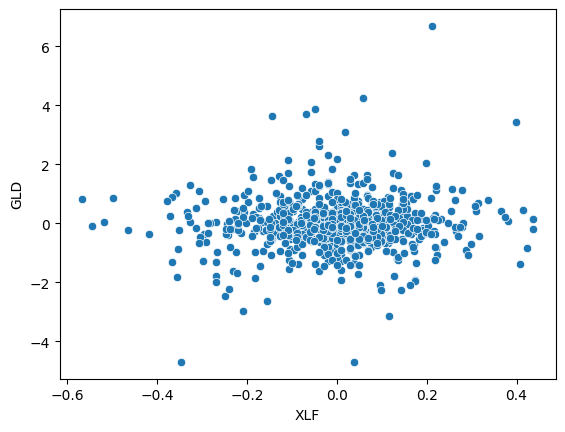

In [7]:
ax = sns.scatterplot(data=etfs, x='XLF', y='GLD');

Y vemos que en efecto las variables GLD y XLF no están prácticamente correlacionadas: un aumento/disminución en XLF no implica un aumento/disminución proporcional de GLD.

En ocasiones resulta útil mostrar el índice de correlación correspondiente superpuesto a la gráfica anterior. Para esto importamos Matplotlib y agregamos la anotación con el método `text()`:

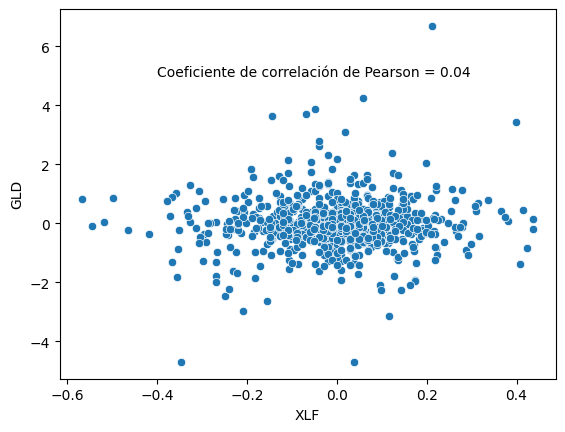

In [8]:
# Scatter plots con coeficiente de correlación
import matplotlib.pyplot as plt

# Gráfico de dispersión
ax = sns.scatterplot(data=etfs, x='XLF', y='GLD')

# Coeficiente de correlación
coef = etfs['XLF'].corr(etfs['GLD'])

# Anotación
plt.text(-0.4, 5, f'Coeficiente de correlación de Pearson = {coef:.2f}');

Y la idea es que podemos realizar este tipo de gráficas para pares de variables que consideremos relevantes para nuestro análisis.

Por ejemplo, volvamos a los ETFs QQQ y XLK que tienen un alto grado de correlación. Veamos la gráfica de dispersión y el correspondiente valor de su índice de correlación:

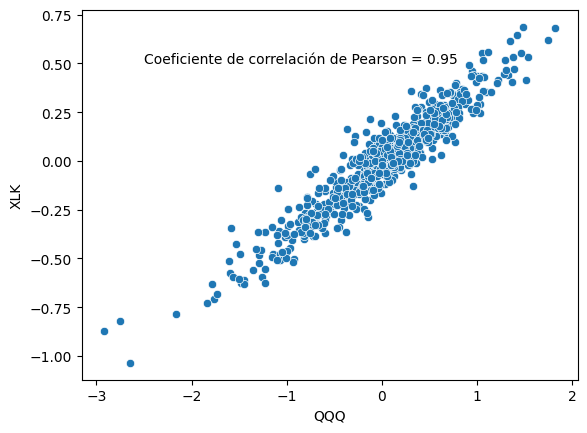

In [9]:
# Gráfico de dispersión
ax = sns.scatterplot(data=etfs, x='QQQ', y='XLK')

# Coeficiente de correlación
coef = etfs['QQQ'].corr(etfs['XLK'])

# Anotación
plt.text(-2.5, 0.5, f'Coeficiente de correlación de Pearson = {coef:.2f}');

Y acá vemos una correlación directa (coeficiente de 0.95) que nos indica que cuando una variable aumenta/disminuye la otra lo hace en la misma proporción.

Veamos lo que ocurre cuando hay un cierto grado de correlación inversa, analizando por ejemplo VXX y SPY:

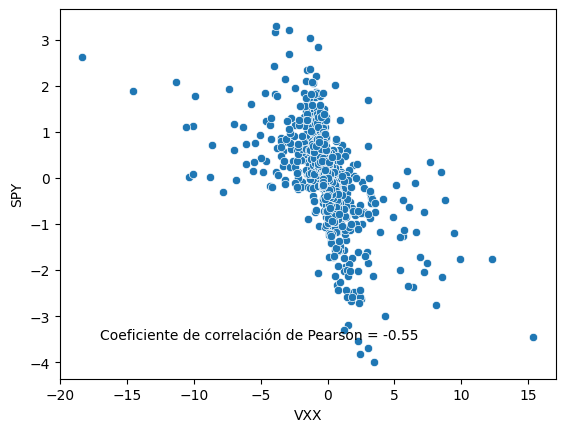

In [10]:
# Gráfico de dispersión
ax = sns.scatterplot(data=etfs, x='VXX', y='SPY')

# Coeficiente de correlación
coef = etfs['VXX'].corr(etfs['SPY'])

# Anotación
plt.text(-17, -3.5, f'Coeficiente de correlación de Pearson = {coef:.2f}');

Aunque no es totalmente inversa la relación (coeficiente de -0.55) si vemos que un aumento/disminución en VXX genera una disminución/aumento en SPY.

En ocasiones (si no tenemos demasiadas variables) podemos dibujar una "matriz de dispersión" que contiene los gráficos de dispersión de todos los posibles pares de combinaciones de variables en el *DataFrame*.

Esto lo podemos hacer usando el método `scatter_matrix` de Pandas:

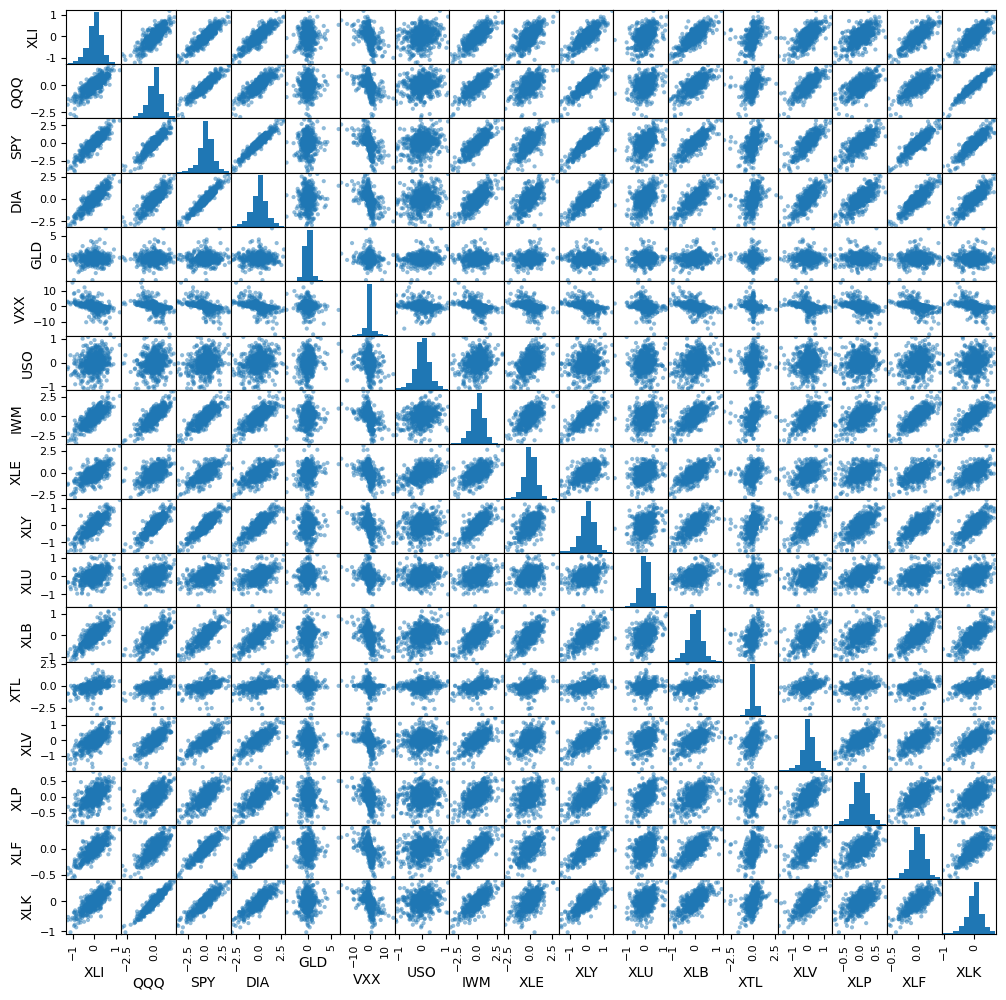

In [12]:
# Matriz de dispersión (podrá tomar un tiempo generar la gráfica dependiendo de la cantidad de datos
# y de las capacidades de cómputo que tengamos)
pd.plotting.scatter_matrix(etfs, figsize=(12,12));

## 4. Mapas hexagonales (*hex binings*) y curvas de contorno (*contour maps*)

En el ejemplo anterior cada variable tenía un total de 754 datos. Sin embargo, cuando tenemos "muchos" registros en ocasiones el uso de gráficos de dispersión no facilita la visualización del comportamiento de los datos.

Por ejemplo, carguemos el set de datos *tax-data.csv* que contiene registros históricos de los impuestos pagados por habitantes de un condado de Washington:

In [13]:
tax = pd.read_csv('/Users/miguel/Downloads/tax-data.csv')
tax

,TaxAssessedValue,SqFtTotLiving,ZipCode
0,206000.0,1870,98002.0
1,303000.0,1530,98166.0
2,361000.0,2000,98108.0
3,459000.0,3150,98108.0
4,223000.0,1570,98032.0
...,...,...,...
467358,375000.0,2230,98056.0
467359,316000.0,1710,98056.0
467360,340000.0,1930,98056.0
467361,132000.0,2930,98056.0


¡Ahora, en lugar de 754 datos tenemos 467.363 registros!

Si generamos un gráfico de dispersión para comparar las dos variables numéricas (*TaxAssessedValue* y *SqFtTotLiving*) no resultará fácil interpretar el resultado:

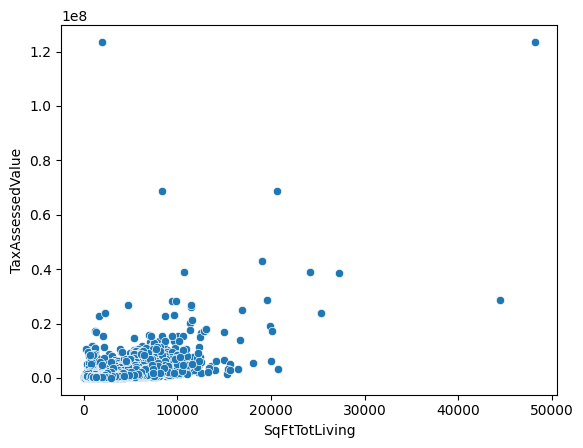

In [14]:
# Scatter plot TaxAssessedValue	 vs SqFtTotLiving
ax = sns.scatterplot(data=tax, x='SqFtTotLiving', y='TaxAssessedValue')

En la parte inferior izquierda estará agrupada la mayor parte de los datos y estos no se pueden diferenciar fácilmente pues los puntos se superponen.

Una alternativa es por ejemplo filtrar algunos datos y generar nuevamente la gráfica. Por ejemplo, tomemos estos criterios para el filtrado:

- $1000\leq SqFtTotLiving \leq 3000$
- $100000\leq TaxAssessedValue \leq 400000$

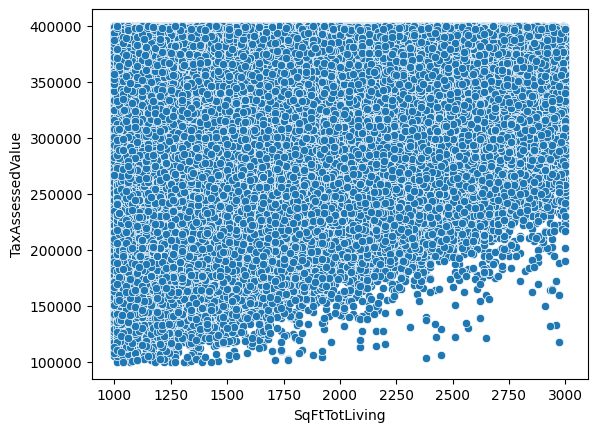

In [15]:
# Filtrar
tax_filt = tax.loc[(tax['TaxAssessedValue'] <= 400000) &
                   (tax['TaxAssessedValue'] >= 100000) &
                   (tax['SqFtTotLiving'] >= 1000) &
                   (tax['SqFtTotLiving'] <= 3000), :]

# Y dibujar gráfico de dispersión
ax = sns.scatterplot(data=tax_filt, x='SqFtTotLiving', y='TaxAssessedValue');

Pero vemos que en todo caso resulta difícil interpretar este resultado pues vemos simplemente una mancha uniforme de puntos.

Una alternativa es usar un mapa hexagonal que:

1. Divide cada variable numérica en un número específico de intervalos
2. Por cada intervalo crea un "bin" hexagonal
3. Por cada hexágono calcula la cantidad de datos (provenientes de ambas variables) que se encuentran dentro del "bin"
4. Dibuja el resultado en una gráfica

Por ejemplo, generemos el mapa hexagonal de las variables anteriores (filtradas) usando un total de 20 intervalos. Para generar el mapa usaremos `jointplot()` de Seaborn:

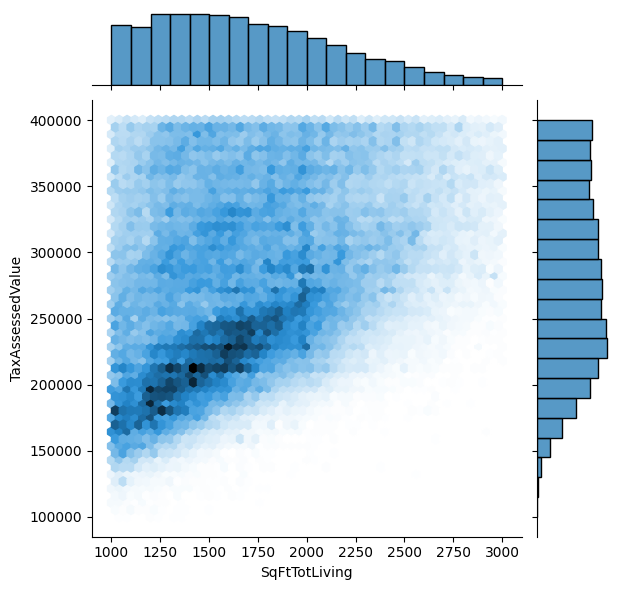

In [16]:
# Mapa hexagonal sobre el dataframe filtrado
ax = sns.jointplot(x=tax_filt['SqFtTotLiving'], y=tax['TaxAssessedValue'], 
                   kind="hex", # Para obtener un mapa hexagonal
                   marginal_kws=dict(bins=20), # Número de bins
                  )

Y vemos algunos elementos importantes en esta gráfica:

- A cada variable se superpone el histograma individual calculado usando el número de bins especificado
- Los hexágonos con tonalidades claras contienen pocos datos, mientras que los hexágonos más oscuros contienen más datos

Y con este gráfico ya podemos ver unos ciertos patrones que nos facilitan el análisis exploratorio. Por ejemplo:

- Las regiones más densas del gráfico están en los rangos de 1.250 a 1.800 para "SqFtTotLiving" y de 150.000 a 250.000 para "TaxAssessedValue"
- Las regiones menos densas están por encima de 2.750 para "SqFtTotLiving" y aproximadamente 300.000 para "TaxAssessedValue"

Lo anterior nos permite afirmar que la mayor parte de las viviendas dentro del condado están de los 1.250 a los 1.800 pies cuadrados y valoradas entre 150.000 y 250.000 dólares.

Un tipo de gráfico equivalente a los mapas hexagonales son las curvas de contorno. En este caso:

1. Se estima la distribución de cada dato (en este caso la distribución es bidimensional)
2. La distribución obtenida es una función 3D: depende de los variables y el valor de la distribución es la tercera dimensión
3. Las distribuciones superpuestas se muestran en un gráfico 2D con el valor de la distribución codificado con un color

Para obtener este tipo de gráfico podemos usar el método `kdeplot()` de Seaborn (nota importante: si tenemos demasiados datos el tiempo requerido para generar la gráfica será significativo):

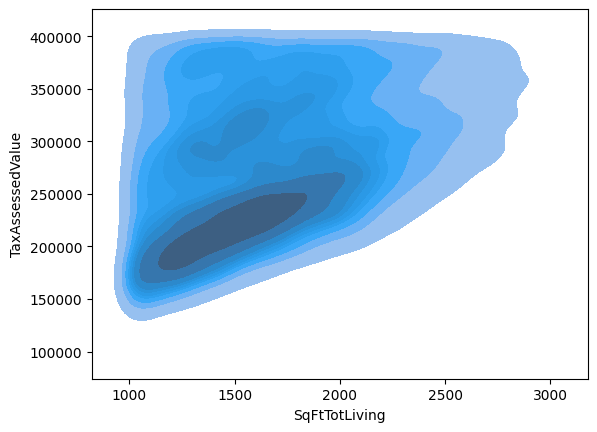

In [17]:
ax = sns.kdeplot(x=tax_filt['SqFtTotLiving'], y=tax_filt['TaxAssessedValue'], fill=True)

## 5. Aspectos a tener en cuenta

- Podemos usar la correlación para **cuantificar** el grado de relación entre pares de variables numéricas.
- Cuando tenemos muchas variables numéricas lo más adecuado es: (1) calcular la matriz de correlación y (2) dibujarla usando mapas de calor
- Usar **gráficos de dispersión** cuando queremos ver en detalle relaciones entre pares específicos de variables, superponiendo al gráfico el **coeficiente de correlación de Pearson**
- Cuando tenemos varios miles de registros resulta más conveniente visualizar relaciones entre pares de variables usando **mapas hexagonales** o **curvas de contorno**